# Cross-Dataset Comparison: Proxemics & Social Synchrony

Pulls together the three core study datasets -- **ConfLab** (real-world
cocktail-party mingling, F-formations), **Hybrid** (F2F vs. VR-mediated,
`2_2_2`/`6_1` group structures), and **Fashion** (Historical vs. Neutral
roleplay dyads) -- and puts their proxemics and social-synchrony results on
directly comparable, shared-scale figures.

Everything here is computed from the raw session files, not copied from the
per-dataset notebooks -- this notebook is self-contained and re-runnable on
its own.

## 0. Imports & configuration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, str(Path('../lib').resolve()))
from xr_analysis import resample_session, estimate_native_hz, direction_sync_all_pairs
from xr_groups import (
    load_conflab_episode_variant, load_conflab_full_session, classify_formation_distances,
    load_hybrid_dataset, pairwise_distances_within_file, load_fashion_dataset,
    plot_proxemic_distribution, plot_sync_score_boxplot,
    HYBRID_CONDITIONS, FASHION_CONDITION_LABEL,
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

DATA_DIR = Path('../Data')
LEGEND_LABEL = {'F2F': 'F2F', '6_1': '6-1', '2_2_2': '2-2-2'}
TLABEL = {'introductions': 'Introductions', 'worstmeal': 'Worst Meal'}

## 1. Load all three datasets

ConfLab is loaded in both forward-facing variants (head orientation vs.
shoulder vector) plus the full ~45-participant session (needed for
F-formation membership classification). Hybrid and Fashion are each a
single native-schema load.

In [2]:
ep_head, intervals_head = load_conflab_episode_variant(DATA_DIR / 'conflab_head', 'conflab_head')
ep_shoulders, intervals_shoulders = load_conflab_episode_variant(DATA_DIR / 'conflab_shoulders', 'conflab_shoulders')
full_session = load_conflab_full_session(DATA_DIR / 'conflab_session.csv')
print(f"ConfLab: {len(intervals_head)} episodes, {ep_head['participant_id'].nunique()} unique participants (episodes), "
      f"{full_session['participant_id'].nunique()} participants (full session)")

ConfLab: 17 episodes, 39 unique participants (episodes), 45 participants (full session)


In [3]:
hybrid_long, hybrid_specs = load_hybrid_dataset(DATA_DIR / 'hybrid')
print(f"Hybrid: {len(hybrid_specs)} group/condition/task files, {hybrid_long['participant_id'].nunique()} unique participant IDs")

Hybrid: 24 group/condition/task files, 23 unique participant IDs


In [4]:
fashion_long, fashion_specs = load_fashion_dataset(DATA_DIR / 'fashion')
print(f"Fashion: {len(fashion_specs)} dyad sessions, {dict(fashion_specs['condition'].value_counts())}")

Fashion: 28 dyad sessions, {'H': np.int64(14), 'N': np.int64(14)}


## 2. Proxemics distances

Same pairwise-3D-distance computation, three different groupings: ConfLab
splits by F-formation membership (within vs. cross), Hybrid and Fashion
split by experimental condition.

In [5]:
formation_dists = classify_formation_distances(intervals_head, full_session, rate_hz=1.0)
for label, d in formation_dists.items():
    print(f"  {label:6s}: n={len(d):>7,}  mean={d.mean():.3f} m  median={np.median(d):.3f} m")

  within: n= 27,327  mean=1.450 m  median=1.012 m
  cross : n=751,233  mean=3.115 m  median=3.025 m


In [6]:
hybrid_dists = {}  # (task, condition) -> distances
for task in ['introductions', 'worstmeal']:
    for cond in HYBRID_CONDITIONS:
        sub = hybrid_specs[(hybrid_specs.task == task) & (hybrid_specs.condition == cond)]
        parts = []
        for _, row in sub.iterrows():
            file_df = hybrid_long[(hybrid_long.group_id == row.group_id) &
                                   (hybrid_long.condition == cond) & (hybrid_long.task == task)]
            parts.append(pairwise_distances_within_file(file_df, rate_hz=10.0))
        hybrid_dists[(task, cond)] = np.concatenate(parts) if parts else np.array([])
        d = hybrid_dists[(task, cond)]
        print(f"  {task:14s} {LEGEND_LABEL[cond]:6s}: mean={d.mean():.3f} m  (n={len(d):,})")

  introductions  F2F   : mean=0.941 m  (n=6,050)


  introductions  6-1   : mean=0.836 m  (n=5,970)


  introductions  2-2-2 : mean=0.934 m  (n=5,610)


  worstmeal      F2F   : mean=0.935 m  (n=35,340)


  worstmeal      6-1   : mean=0.930 m  (n=32,676)


  worstmeal      2-2-2 : mean=0.874 m  (n=33,060)


In [7]:
fashion_dists = {}
for cond in ['H', 'N']:
    sub = fashion_specs[fashion_specs.condition == cond]
    parts = [pairwise_distances_within_file(fashion_long[fashion_long.pair_id == row.pair_id], rate_hz=10.0)
             for _, row in sub.iterrows()]
    fashion_dists[cond] = np.concatenate(parts) if parts else np.array([])
    d = fashion_dists[cond]
    print(f"  {FASHION_CONDITION_LABEL[cond]:12s}: mean={d.mean():.3f} m  (n={len(d):,})")

  Historical  : mean=5.121 m  (n=127,282)


  Neutral     : mean=5.278 m  (n=111,900)


## 3. Social synchrony (aggregate direction-sync score)

Per pair: frame-to-frame delta of each person's facing-direction vector,
Pearson-correlated per axis and summed (skipping structurally-constant
axes rather than propagating NaN). ConfLab is computed for **both**
forward-facing definitions -- head orientation and shoulder vector --
pooled across all 17 episodes, since position is identical between the two
but the direction signal differs.

In [8]:
def conflab_pooled_sync(ep_df):
    parts = []
    for episode_id, g in ep_df.groupby('episode_id'):
        hz = round(estimate_native_hz(g))
        res = resample_session(g, rate_hz=hz)
        ds = direction_sync_all_pairs(res)
        parts.append(ds.assign(episode_id=episode_id))
    return pd.concat(parts, ignore_index=True)

conflab_pairs_head = conflab_pooled_sync(ep_head)
conflab_pairs_shoulders = conflab_pooled_sync(ep_shoulders)
print(f"ConfLab head:      n_pairs={len(conflab_pairs_head)}  mean={conflab_pairs_head['corr_agg'].mean():.4f}")
print(f"ConfLab shoulders: n_pairs={len(conflab_pairs_shoulders)}  mean={conflab_pairs_shoulders['corr_agg'].mean():.4f}")

ConfLab head:      n_pairs=99  mean=0.1130
ConfLab shoulders: n_pairs=99  mean=0.0637


In [9]:
rows = []
for (gid, cond, task), g in hybrid_long.groupby(['group_id', 'condition', 'task']):
    hz = round(estimate_native_hz(g))
    if not np.isfinite(hz) or hz < 1:
        continue
    res = resample_session(g, rate_hz=hz)
    ds = direction_sync_all_pairs(res)
    for _, r in ds.iterrows():
        rows.append({'group_id': gid, 'condition': cond, 'task': task, **r.to_dict()})
hybrid_pairs = pd.DataFrame(rows)
print(f"Hybrid: n_pairs={len(hybrid_pairs)}  mean={hybrid_pairs['corr_agg'].mean():.4f}")

Hybrid: n_pairs=48  mean=0.0184


In [10]:
rows = []
for pair_id, g in fashion_long.groupby('pair_id'):
    hz = round(estimate_native_hz(g))
    res = resample_session(g, rate_hz=hz)
    ds = direction_sync_all_pairs(res)
    cond = fashion_specs.loc[fashion_specs.pair_id == pair_id, 'condition'].iloc[0]
    for _, r in ds.iterrows():
        rows.append({'pair_id': pair_id, 'condition': cond, **r.to_dict()})
fashion_pairs = pd.DataFrame(rows)
print(f"Fashion: n_pairs={len(fashion_pairs)}  mean={fashion_pairs['corr_agg'].mean():.4f}")

Fashion: n_pairs=28  mean=-0.0004


## 4. Figure 1 -- Proxemics across datasets

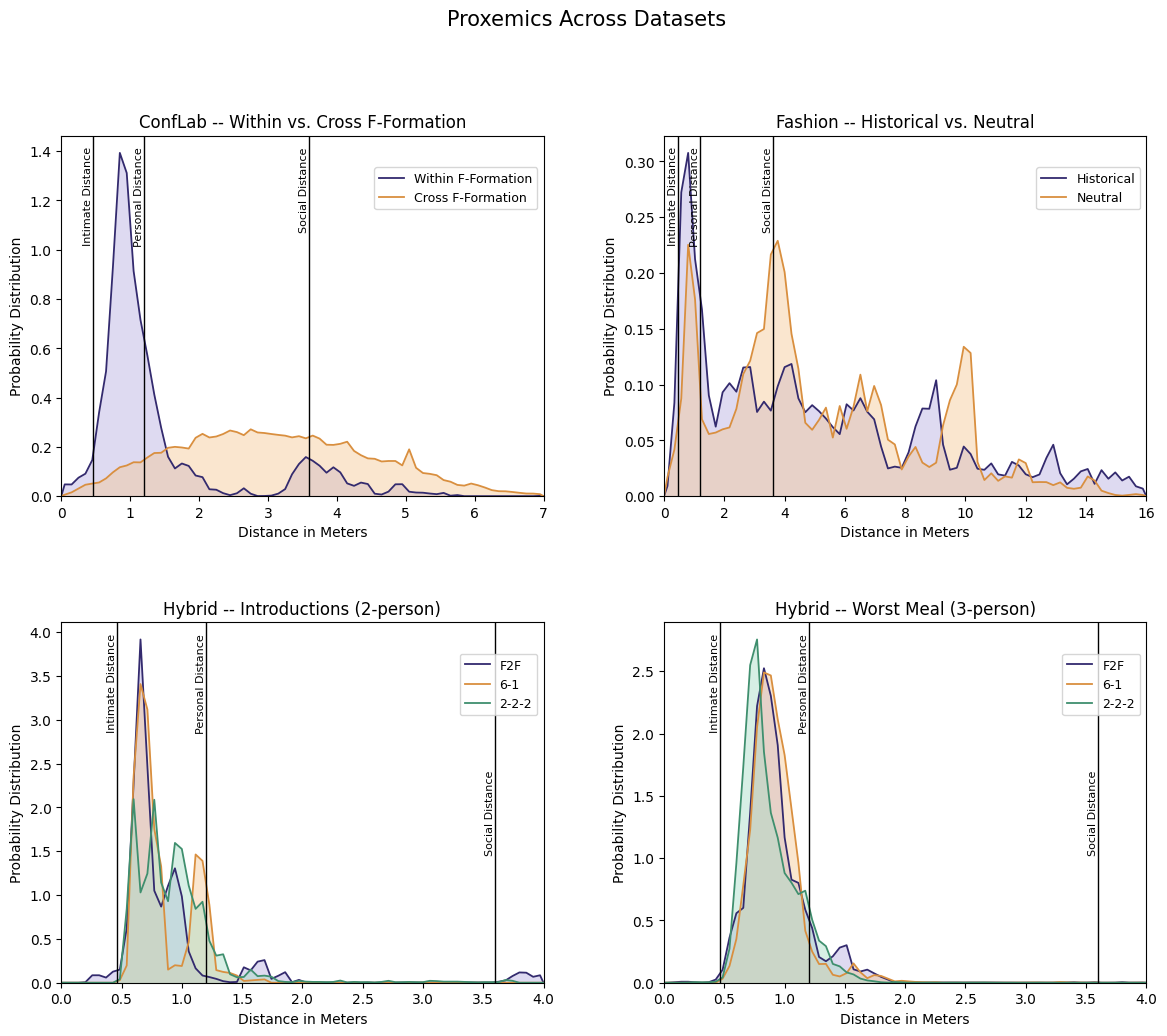

In [11]:
fig1 = plt.figure(figsize=(14, 11))
gs1 = gridspec.GridSpec(2, 2, figure=fig1, hspace=0.35, wspace=0.25)

ax_conflab = fig1.add_subplot(gs1[0, 0])
plot_proxemic_distribution(
    ax_conflab,
    {'Within F-Formation': formation_dists['within'], 'Cross F-Formation': formation_dists['cross']},
    'ConfLab -- Within vs. Cross F-Formation', xmax=7.0,
)

ax_fashion = fig1.add_subplot(gs1[0, 1])
plot_proxemic_distribution(
    ax_fashion,
    {FASHION_CONDITION_LABEL[c]: fashion_dists[c] for c in ['H', 'N']},
    'Fashion -- Historical vs. Neutral', xmax=16.0,
)

ax_hyb_intro = fig1.add_subplot(gs1[1, 0])
plot_proxemic_distribution(
    ax_hyb_intro,
    {LEGEND_LABEL[c]: hybrid_dists[('introductions', c)] for c in HYBRID_CONDITIONS},
    'Hybrid -- Introductions (2-person)', xmax=4.0,
)

ax_hyb_meal = fig1.add_subplot(gs1[1, 1])
plot_proxemic_distribution(
    ax_hyb_meal,
    {LEGEND_LABEL[c]: hybrid_dists[('worstmeal', c)] for c in HYBRID_CONDITIONS},
    'Hybrid -- Worst Meal (3-person)', xmax=4.0,
)

fig1.suptitle('Proxemics Across Datasets', fontsize=15, y=0.995)
plt.savefig('comparison_proxemics_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Figure 2 -- Synchrony across datasets

Top row: ConfLab's per-episode breakdown (head-based), which needs its own
scale since episode ep10 is a genuine outlier. Bottom row: the three
between-dataset comparisons -- ConfLab head vs. shoulders, Hybrid by
condition x task, Fashion by condition -- sharing one y-axis so box heights
are directly comparable. The shared axis is set from each box's actual
whisker extent (`Q1-1.5*IQR` to `Q3+1.5*IQR`), not raw min/max, since raw
min/max is dominated by the same ep10 outlier pairs that `showfliers=False`
already hides from view.

In [12]:
data_by_ep = {ep: conflab_pairs_head.loc[conflab_pairs_head.episode_id == ep, 'corr_agg'].to_numpy()
              for ep in sorted(conflab_pairs_head['episode_id'].unique())}
data_hs = {'Head': conflab_pairs_head['corr_agg'].to_numpy(), 'Shoulders': conflab_pairs_shoulders['corr_agg'].to_numpy()}
data_hybrid = {f"{TLABEL[task]}\n{LEGEND_LABEL[cond]}": hybrid_pairs.loc[(hybrid_pairs.task == task) & (hybrid_pairs.condition == cond), 'corr_agg'].to_numpy()
               for task in ['introductions', 'worstmeal'] for cond in HYBRID_CONDITIONS}
data_fashion = {FASHION_CONDITION_LABEL[c]: fashion_pairs.loc[fashion_pairs.condition == c, 'corr_agg'].to_numpy() for c in ['H', 'N']}

def whisker_extent(arr):
    """Matches matplotlib boxplot's default whisker rule -- showfliers=False
    hides anything beyond this, so this (not raw min/max) is what's visible."""
    a = arr[np.isfinite(arr)]
    if len(a) == 0:
        return np.nan, np.nan
    q1, q3 = np.percentile(a, [25, 75])
    iqr = q3 - q1
    return max(a.min(), q1 - 1.5 * iqr), min(a.max(), q3 + 1.5 * iqr)

whisk_los, whisk_his = [], []
for d in [data_hs, data_hybrid, data_fashion]:
    for v in d.values():
        lo, hi = whisker_extent(v)
        whisk_los.append(lo); whisk_his.append(hi)
lo, hi = min(whisk_los), max(whisk_his)
pad = 0.08 * (hi - lo)
shared_ylim = (lo - pad, hi + pad)
print(f"Shared ylim for bottom row: {shared_ylim}")

Shared ylim for bottom row: (np.float64(-0.36285102896169774), np.float64(0.3260031438226708))


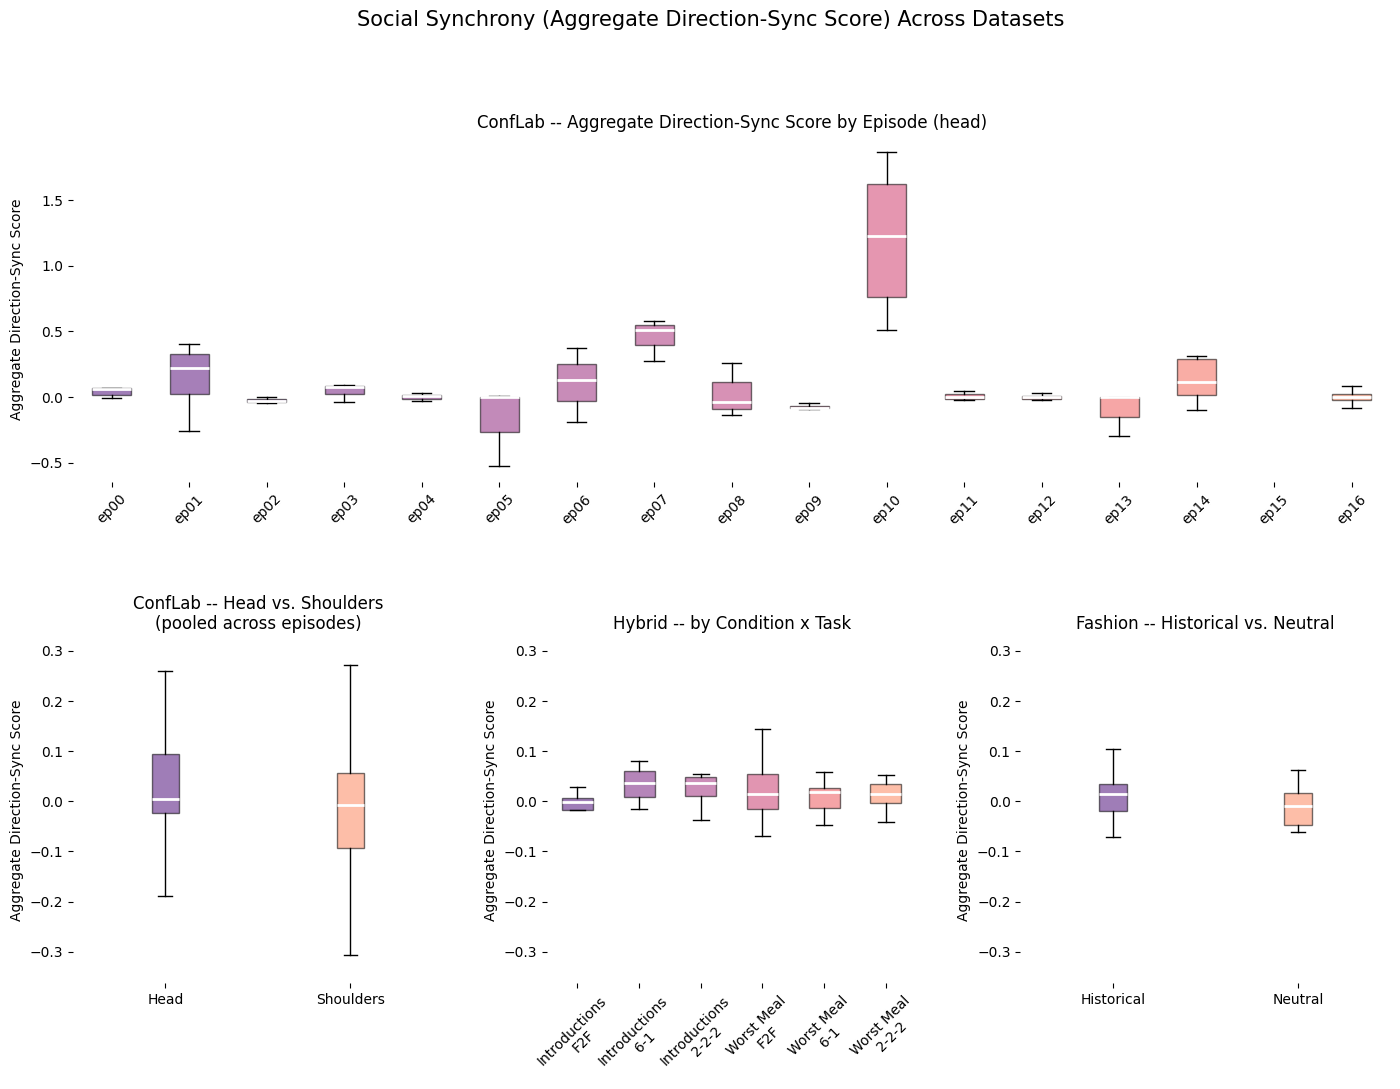

In [13]:
fig2 = plt.figure(figsize=(17, 11))
gs2 = gridspec.GridSpec(2, 3, figure=fig2, height_ratios=[1, 1], hspace=0.45, wspace=0.28)

ax_ep = fig2.add_subplot(gs2[0, :])
plot_sync_score_boxplot(ax_ep, data_by_ep, 'ConfLab -- Aggregate Direction-Sync Score by Episode (head)', rotate_labels=True)

ax_hs = fig2.add_subplot(gs2[1, 0])
plot_sync_score_boxplot(ax_hs, data_hs, 'ConfLab -- Head vs. Shoulders\n(pooled across episodes)')
ax_hs.set_ylim(*shared_ylim)

ax_hyb = fig2.add_subplot(gs2[1, 1])
plot_sync_score_boxplot(ax_hyb, data_hybrid, 'Hybrid -- by Condition x Task', rotate_labels=True)
ax_hyb.set_ylim(*shared_ylim)

ax_fash = fig2.add_subplot(gs2[1, 2])
plot_sync_score_boxplot(ax_fash, data_fashion, 'Fashion -- Historical vs. Neutral')
ax_fash.set_ylim(*shared_ylim)

fig2.suptitle('Social Synchrony (Aggregate Direction-Sync Score) Across Datasets', fontsize=15, y=0.995)
plt.savefig('comparison_synchrony_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Figure 3 -- Synchrony, all datasets combined

Every non-per-episode box from Figure 2's bottom row on one axis, grouped
and labeled by dataset, same shared scale.

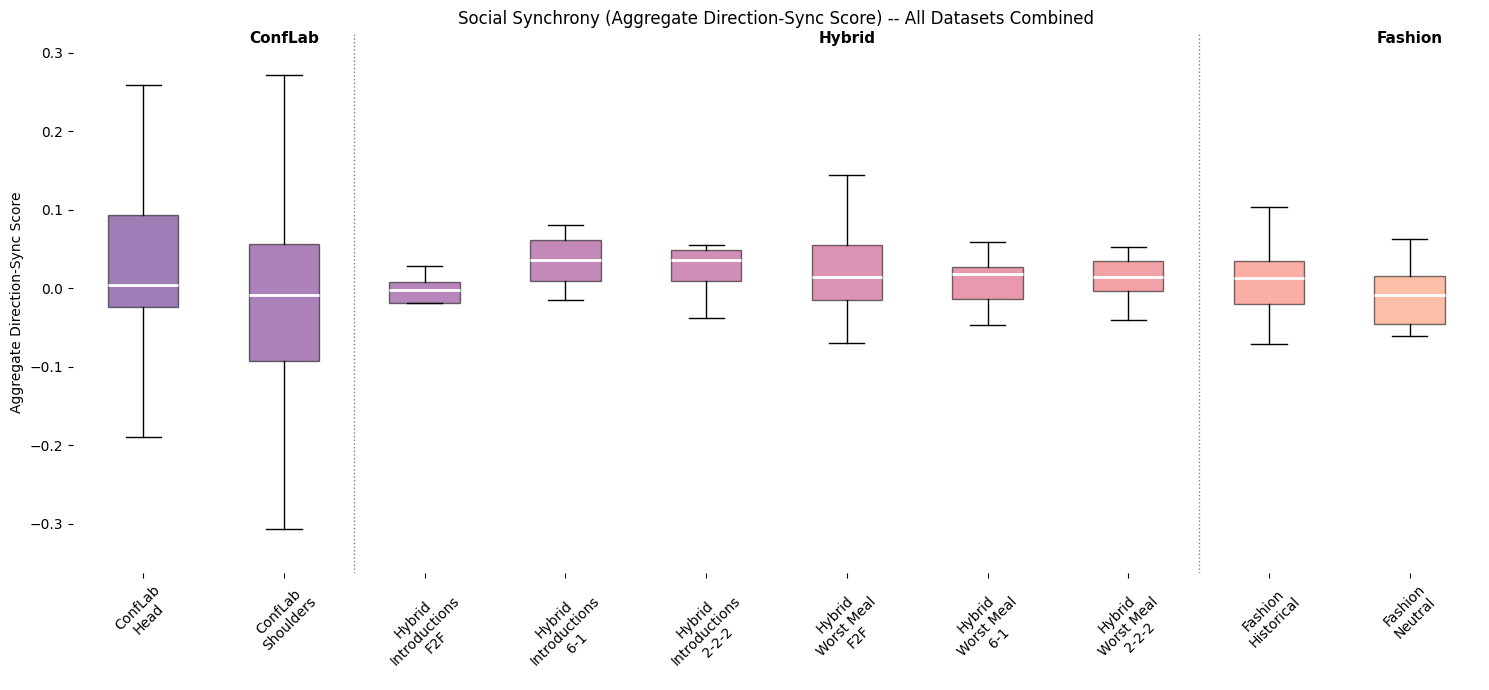

In [14]:
combined = {'ConfLab\nHead': data_hs['Head'], 'ConfLab\nShoulders': data_hs['Shoulders']}
for k, v in data_hybrid.items():
    combined[f'Hybrid\n{k}'] = v
combined['Fashion\nHistorical'] = data_fashion['Historical']
combined['Fashion\nNeutral'] = data_fashion['Neutral']

fig3, ax3 = plt.subplots(figsize=(15, 7))
plot_sync_score_boxplot(ax3, combined, 'Social Synchrony (Aggregate Direction-Sync Score) -- All Datasets Combined', rotate_labels=True)
ax3.set_ylim(*shared_ylim)

n_conflab, n_hybrid, n_fashion = 2, 6, 2
div1, div2 = n_conflab + 0.5, n_conflab + n_hybrid + 0.5
ax3.axvline(div1, color='gray', linestyle=':', linewidth=1)
ax3.axvline(div2, color='gray', linestyle=':', linewidth=1)

ylim3 = ax3.get_ylim()
ytop = ylim3[1]
ytxt = ytop - 0.02 * (ylim3[1] - ylim3[0])
ax3.text((1 + n_conflab) / 2 + 0.5, ytxt, 'ConfLab', ha='center', fontsize=11, fontweight='bold')
ax3.text(n_conflab + (n_hybrid + 1) / 2 + 0.5, ytxt, 'Hybrid', ha='center', fontsize=11, fontweight='bold')
ax3.text(n_conflab + n_hybrid + (n_fashion + 1) / 2 + 0.5, ytxt, 'Fashion', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_synchrony_combined_single.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

In [15]:
print('=== Proxemics (mean distance, m) ===')
print(f"  ConfLab within:  {formation_dists['within'].mean():.3f}   ConfLab cross: {formation_dists['cross'].mean():.3f}")
for (task, cond), d in hybrid_dists.items():
    print(f"  Hybrid {task:14s} {LEGEND_LABEL[cond]:6s}: {d.mean():.3f}")
for c in ['H', 'N']:
    print(f"  Fashion {FASHION_CONDITION_LABEL[c]:10s}: {fashion_dists[c].mean():.3f}")
print()
print('=== Social synchrony (mean aggregate direction-sync score) ===')
print(f"  ConfLab head:      {conflab_pairs_head['corr_agg'].mean():.4f}")
print(f"  ConfLab shoulders: {conflab_pairs_shoulders['corr_agg'].mean():.4f}")
for task in ['introductions', 'worstmeal']:
    for cond in HYBRID_CONDITIONS:
        v = hybrid_pairs.loc[(hybrid_pairs.task == task) & (hybrid_pairs.condition == cond), 'corr_agg'].mean()
        print(f"  Hybrid {task:14s} {LEGEND_LABEL[cond]:6s}: {v:.4f}")
for c in ['H', 'N']:
    v = fashion_pairs.loc[fashion_pairs.condition == c, 'corr_agg'].mean()
    print(f"  Fashion {FASHION_CONDITION_LABEL[c]:10s}: {v:.4f}")

=== Proxemics (mean distance, m) ===
  ConfLab within:  1.450   ConfLab cross: 3.115
  Hybrid introductions  F2F   : 0.941
  Hybrid introductions  6-1   : 0.836
  Hybrid introductions  2-2-2 : 0.934
  Hybrid worstmeal      F2F   : 0.935
  Hybrid worstmeal      6-1   : 0.930
  Hybrid worstmeal      2-2-2 : 0.874
  Fashion Historical: 5.121
  Fashion Neutral   : 5.278

=== Social synchrony (mean aggregate direction-sync score) ===
  ConfLab head:      0.1130
  ConfLab shoulders: 0.0637
  Hybrid introductions  F2F   : -0.0087
  Hybrid introductions  6-1   : 0.0342
  Hybrid introductions  2-2-2 : 0.0226
  Hybrid worstmeal      F2F   : 0.0244
  Hybrid worstmeal      6-1   : 0.0066
  Hybrid worstmeal      2-2-2 : 0.0267
  Fashion Historical: 0.0092
  Fashion Neutral   : -0.0100
